In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset/mental_health_burnout_prediction_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (50000, 40)


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


In [6]:
import os

for dirname, _, filenames in os.walk(
    "/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset"
):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset/mental_health_burnout_prediction_dataset.csv


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 50000
Columns: 40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person_ID                      50000 non-null  int64  
 1   Age                            49750 non-null  float64
 2   Gender                         50000 non-null  object 
 3   Country                        50000 non-null  object 
 4   Occupation                     50000 non-null  object 
 5   Education_Level                50000 non-null  object 
 6   Employment_Status              50000 non-null  object 
 7   Monthly_Income_USD             48550 non-null  float64
 8   Work_Hours_Per_Week            50000 non-null  int64  
 9   Remote_Work                    50000 non-null  object 
 10  Job_Satisfaction               49500 non-null  float64
 11  Work_Life_Balance              49350 non-null  float64
 12  Sleep_Hours           

In [8]:
print(df["Burnout_Risk"].value_counts())

print("\nPercentages:")
print(df["Burnout_Risk"].value_counts(normalize=True) * 100)

Burnout_Risk
Low         25369
Moderate    14780
High         9851
Name: count, dtype: int64

Percentages:
Burnout_Risk
Low         50.738
Moderate    29.560
High        19.702
Name: proportion, dtype: float64


In [9]:
print(df.groupby("Burnout_Risk")["Burnout_Score"].describe())

                count       mean        std   min   25%   50%   75%    max
Burnout_Risk                                                              
High           9851.0  79.186174  10.655923  65.0  70.0  77.0  87.0  100.0
Low           25369.0  18.677717  12.588023   0.0   8.0  19.0  30.0   39.0
Moderate      14780.0  51.163464   7.091750  40.0  45.0  51.0  57.0   64.0


## Target Variable Analysis

The target variable for this project is **`Burnout_Risk`**, which is a multiclass classification variable with three categories: **Low, Moderate, and High**.

The dataset contains **50,000 observations**. The distribution of the target variable is:

| Burnout Risk |  Count | Percentage |
| ------------ | -----: | ---------: |
| Low          | 25,369 |     50.74% |
| Moderate     | 14,780 |     29.56% |
| High         |  9,851 |     19.70% |

The classes are not perfectly balanced, with **Low burnout risk** representing the largest group. However, the imbalance is not extreme, so we will first evaluate our models using the original data before considering techniques such as class weighting or resampling.

### Potential Data Leakage

An important observation was identified when examining the relationship between **`Burnout_Risk`** and **`Burnout_Score`**. The `Burnout_Score` ranges correspond very closely to the three target categories:

* **Low:** 0–39
* **Moderate:** 40–64
* **High:** 65–100

This suggests that `Burnout_Risk` may have been derived directly from `Burnout_Score`. Including `Burnout_Score` as a predictor could therefore cause **data leakage**, allowing the model to predict the target using information that was effectively used to create the target itself.

For this reason, **`Burnout_Score` will be excluded from the predictive features**. Other variables will also be examined for possible leakage before model training.

This will allow the machine learning and deep learning models to learn meaningful relationships between the available mental health, workplace, lifestyle, and demographic factors and the individual's burnout risk.


In [10]:
#EDA
# Step 3: Dataset structure

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Missing %,Unique Values
Person_ID,int64,0,0.0,50000
Age,float64,250,0.5,48
Gender,object,0,0.0,3
Country,object,0,0.0,25
Occupation,object,0,0.0,20
Education_Level,object,0,0.0,5
Employment_Status,object,0,0.0,4
Monthly_Income_USD,float64,1450,2.9,11339
Work_Hours_Per_Week,int64,0,0.0,51
Remote_Work,object,0,0.0,3


In [11]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Person_ID', 'Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Categorical columns:
['Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


In [12]:
# Examine categorical variables

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))


Gender:
Gender
Female    16810
Male      16681
Other     16509
Name: count, dtype: int64

Country:
Country
South Africa     2098
Canada           2061
Russia           2051
Saudi Arabia     2043
Pakistan         2039
Spain            2031
Turkey           2030
South Korea      2029
France           2021
United States    2014
Name: count, dtype: int64

Occupation:
Occupation
Student              2603
Doctor               2590
Marketing Manager    2552
Nurse                2536
Researcher           2534
Accountant           2532
Designer             2513
Freelancer           2511
Software Engineer    2500
Farmer               2489
Name: count, dtype: int64

Education_Level:
Education_Level
PhD            10052
Diploma        10031
High School    10005
Master          9987
Bachelor        9925
Name: count, dtype: int64

Employment_Status:
Employment_Status
Unemployed       12700
Student          12520
Employed         12414
Self-Employed    12366
Name: count, dtype: int64

Remote_Work:
R

In [13]:
# Descriptive statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Person_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49750.0,41.448181,13.871634,18.0,29.00,41.0,53.00,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.00,6231.0,9134.00,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.00,45.0,58.00,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.00,6.0,8.00,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.50,7.0,8.50,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.00,39.0,59.00,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.00,39.0,60.00,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.00,61.0,80.00,100.0


In [14]:
# Key numerical variables

key_features = [
    "Age",
    "Monthly_Income_USD",
    "Work_Hours_Per_Week",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Sleep_Hours",
    "Anxiety_Score",
    "Depression_Score",
    "Mood_Score",
    "Emotional_Stability",
    "Physical_Activity_Hours",
    "Meditation_Minutes",
    "Screen_Time_Hours",
    "Social_Media_Hours",
    "Gaming_Hours",
    "Life_Satisfaction",
    "Productivity_Score",
    "Absenteeism_Days"
]

df[key_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


In [15]:
# Compare numerical variables across burnout risk groups

df.groupby("Burnout_Risk")[key_features].mean().T

Burnout_Risk,High,Low,Moderate
Age,41.430275,41.416515,41.514408
Monthly_Income_USD,6264.905485,6260.918367,6225.627746
Work_Hours_Per_Week,57.778804,37.413221,49.322936
Job_Satisfaction,5.495637,5.506805,5.488005
Work_Life_Balance,5.527349,5.505474,5.487259
Sleep_Hours,6.443471,7.299099,6.849239
Anxiety_Score,76.175603,20.621134,50.664190
Depression_Score,76.282197,20.805324,50.771310
Mood_Score,24.473281,79.108619,49.554469
Emotional_Stability,23.994823,79.004848,49.286739


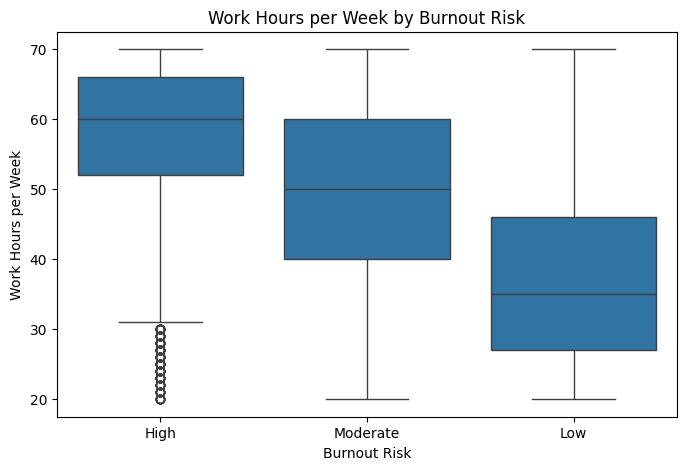

In [16]:
# Burnout Risk vs Work Hours

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Burnout_Risk",
    y="Work_Hours_Per_Week"
)

plt.title("Work Hours per Week by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Work Hours per Week")
plt.show()

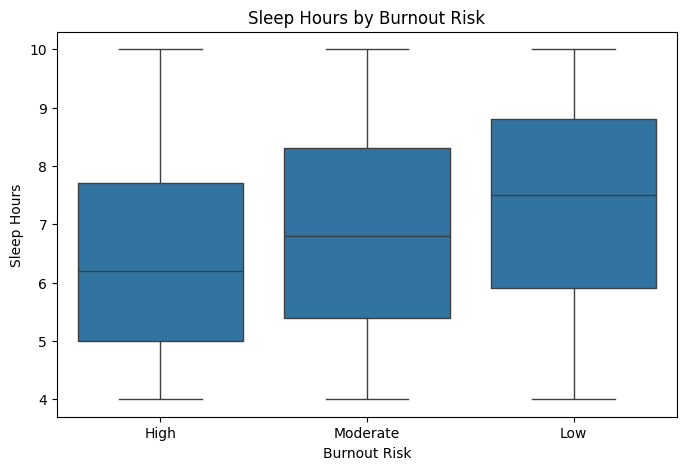

In [17]:
# Burnout Risk vs Sleep Hours

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Burnout_Risk",
    y="Sleep_Hours"
)

plt.title("Sleep Hours by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Sleep Hours")
plt.show()

## Exploratory Data Analysis – Numerical Variables

The descriptive statistics show that the dataset contains a wide range of demographic, workplace, mental-health, lifestyle, and productivity-related variables.

The average age of participants is approximately **41.45 years**, while the average working time is **44.95 hours per week**. Monthly income has a mean of approximately **$6,251**, although there are 1,450 missing income values.

Several variables contain missing observations. The highest number of missing values among the numerical variables occurs in **Meditation_Minutes (1,200)**, followed by **Physical_Activity_Hours (1,100)**, **Sleep_Hours (950)**, and **Productivity_Score (950)**. These missing values will be handled later during the preprocessing stage.

### Burnout Risk Patterns

Comparing numerical variables across the three burnout-risk categories revealed several clear patterns.

Employees with **High burnout risk** work an average of **57.78 hours per week**, compared with **49.32 hours** for Moderate burnout risk and **37.41 hours** for Low burnout risk. This suggests a strong positive relationship between working hours and burnout risk.

Sleep duration shows the opposite pattern. Individuals with High burnout risk sleep approximately **6.44 hours per day**, compared with **6.85 hours** for Moderate risk and **7.30 hours** for Low risk.

Mental-health indicators also show substantial differences between the groups. The average **Anxiety Score** increases from **20.62** among the Low-risk group to **50.66** among the Moderate-risk group and **76.18** among the High-risk group. A similar pattern is observed for **Depression Score**, which increases from **20.81** to **50.77** and **76.28**, respectively.

In contrast, **Mood Score** and **Emotional Stability** decrease as burnout risk increases. Mood Score falls from approximately **79.11** in the Low-risk group to **24.47** in the High-risk group, while Emotional Stability decreases from **79.00** to **23.99**.

Productivity also shows a notable difference. The average Productivity Score is approximately **78.69** for Low burnout risk, **49.61** for Moderate risk, and **24.63** for High risk.

### Key EDA Findings

Overall, the analysis indicates that **workload, sleep, anxiety, depression, mood, emotional stability, and productivity** have strong differences across burnout-risk groups. These variables are therefore promising candidates for the predictive models.

Some variables, including **Age, Monthly Income, Job Satisfaction, Social Media Hours, Gaming Hours, and Absenteeism Days**, show relatively small differences in their group means. However, they will not be removed based only on their means because their relationships with other variables may still provide predictive value.

`Person_ID` will be excluded because it is a unique identifier. `Burnout_Score` will also be excluded from model training because its ranges correspond directly to the three `Burnout_Risk` categories, creating a significant risk of target leakage.


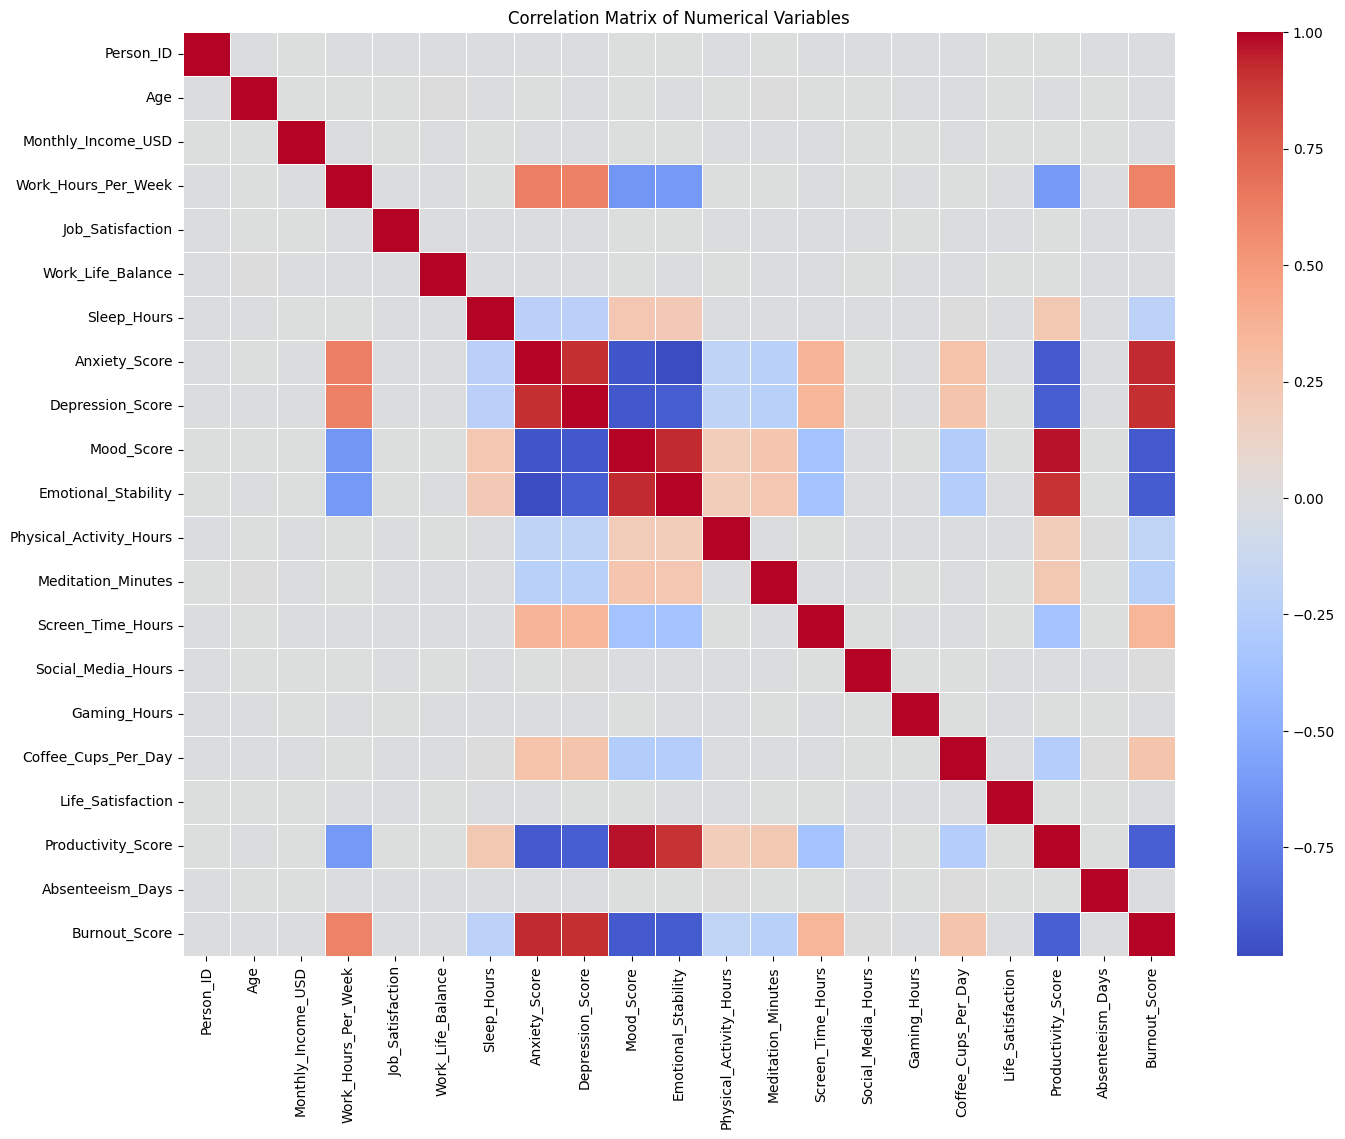

In [18]:
# Correlation matrix for numerical variables

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [19]:
# Correlation of numerical variables with Burnout Score
# This is for EDA only.
# Burnout_Score will NOT be used as a model feature.

burnout_correlations = (
    df[numerical_columns]
    .corr()["Burnout_Score"]
    .sort_values(ascending=False)
)

print(burnout_correlations)

Burnout_Score              1.000000
Anxiety_Score              0.924406
Depression_Score           0.910755
Work_Hours_Per_Week        0.607838
Screen_Time_Hours          0.349397
Coffee_Cups_Per_Day        0.263934
Social_Media_Hours         0.008647
Age                        0.000212
Work_Life_Balance          0.000179
Monthly_Income_USD        -0.001365
Life_Satisfaction         -0.001383
Job_Satisfaction          -0.001729
Gaming_Hours              -0.002213
Absenteeism_Days          -0.003969
Person_ID                 -0.005055
Physical_Activity_Hours   -0.189655
Sleep_Hours               -0.221917
Meditation_Minutes        -0.233005
Productivity_Score        -0.893543
Emotional_Stability       -0.909691
Mood_Score                -0.917170
Name: Burnout_Score, dtype: float64


## Correlation Analysis

A correlation analysis was performed to examine the relationships between the numerical variables in the dataset. Pearson correlation coefficients were used to measure the strength and direction of linear relationships.

The analysis revealed several strong relationships with `Burnout_Score`.

The strongest positive correlations were observed for:

* **Anxiety Score:** 0.924
* **Depression Score:** 0.911
* **Work Hours per Week:** 0.608
* **Screen Time Hours:** 0.349
* **Coffee Cups per Day:** 0.264

These results indicate that higher anxiety, depression, and working hours are strongly associated with higher burnout scores. Screen time and coffee consumption show weaker positive relationships.

Several variables showed negative correlations with burnout:

* **Mood Score:** -0.917
* **Emotional Stability:** -0.910
* **Productivity Score:** -0.894
* **Meditation Minutes:** -0.233
* **Sleep Hours:** -0.222
* **Physical Activity Hours:** -0.190

The strongest negative relationships were observed for Mood Score, Emotional Stability, and Productivity Score. This suggests that higher levels of these variables are associated with lower burnout scores.

In contrast, variables such as **Age (0.000), Work-Life Balance (0.000), Monthly Income (-0.001), Life Satisfaction (-0.001), Job Satisfaction (-0.002), Gaming Hours (-0.002), and Absenteeism Days (-0.004)** showed very weak linear relationships with `Burnout_Score`.

### Important Observation

The correlation results further highlight that `Burnout_Score` is closely related to several mental-health and productivity variables. Since `Burnout_Score` itself appears to determine the `Burnout_Risk` categories, it will **not be included as a predictor in the machine learning or deep learning models**.

The correlation analysis is being used for **exploratory understanding and feature assessment**, rather than as the sole basis for removing features. The final feature set will be determined after considering data leakage, feature types, missing values, and model performance.


In [20]:
# Burnout Risk distribution across categorical variables

categorical_features = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "Remote_Work",
    "Sleep_Quality",
    "Stress_Level",
    "Exercise_Frequency",
    "Alcohol_Consumption",
    "Smoking",
    "Healthy_Diet",
    "Chronic_Stress",
    "Family_History_Mental_Illness",
    "Therapy_Attendance",
    "Support_System",
    "Mental_Health_Status"
]

for col in categorical_features:
    print(f"\n{'='*60}")
    print(f"{col} vs Burnout Risk")
    print(pd.crosstab(df[col], df["Burnout_Risk"], normalize="index").round(3))


Gender vs Burnout Risk
Burnout_Risk   High    Low  Moderate
Gender                              
Female        0.196  0.512     0.291
Male          0.198  0.506     0.296
Other         0.197  0.504     0.299

Education_Level vs Burnout Risk
Burnout_Risk      High    Low  Moderate
Education_Level                        
Bachelor         0.198  0.503     0.299
Diploma          0.203  0.506     0.291
High School      0.198  0.509     0.293
Master           0.192  0.508     0.300
PhD              0.195  0.511     0.294

Employment_Status vs Burnout Risk
Burnout_Risk        High    Low  Moderate
Employment_Status                        
Employed           0.199  0.507     0.293
Self-Employed      0.195  0.510     0.294
Student            0.194  0.513     0.293
Unemployed         0.199  0.500     0.302

Remote_Work vs Burnout Risk
Burnout_Risk   High    Low  Moderate
Remote_Work                         
Hybrid        0.199  0.509     0.292
No            0.197  0.503     0.300
Yes           

In [21]:
# Check the relationship between potentially derived variables
# and Burnout Risk

leakage_features = [
    "Stress_Level",
    "Chronic_Stress",
    "Mental_Health_Status",
    "AI_Wellness_Recommendation"
]

for col in leakage_features:
    print(f"\n{'='*60}")
    print(f"{col} vs Burnout Risk")
    print(pd.crosstab(df[col], df["Burnout_Risk"]))


Stress_Level vs Burnout Risk
Burnout_Risk  High    Low  Moderate
Stress_Level                       
High          6456      0       693
Low              0  20437      1150
Moderate      3395   4932     12937

Chronic_Stress vs Burnout Risk
Burnout_Risk    High    Low  Moderate
Chronic_Stress                       
No              3666  25369     14227
Yes             6185      0       553

Mental_Health_Status vs Burnout Risk
Burnout_Risk          High    Low  Moderate
Mental_Health_Status                       
Critical              9851      0       684
Healthy                  0  25369         0
Needs Attention          0      0     14096

AI_Wellness_Recommendation vs Burnout Risk
Burnout_Risk                High   Low  Moderate
AI_Wellness_Recommendation                      
Improve Sleep               1333  3630      2070
Increase Physical Activity  1410  3646      2134
Maintain Healthy Routine    1430  3779      2137
Practice Mindfulness        1414  3569      2071
Reduce Wor

In [22]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

for col in leakage_features:
    print(f"{col}: {cramers_v(df[col], df['Burnout_Risk']):.4f}")

Stress_Level: 0.7056
Chronic_Stress: 0.7169
Mental_Health_Status: 0.9726
AI_Wellness_Recommendation: 0.0102


## Categorical Feature Analysis and Leakage Assessment

Categorical variables were analyzed by comparing their distribution across the three `Burnout_Risk` categories. Most demographic variables, including gender, education level, employment status, remote-work status, and family history of mental illness, showed relatively similar burnout-risk distributions across their categories.

However, several variables showed much stronger relationships with the target.

`Stress_Level` demonstrated a strong association with burnout risk. Among individuals reporting high stress, **90.3% were classified as having High burnout risk**, while **94.7% of individuals reporting low stress were classified as having Low burnout risk**.

`Chronic_Stress` showed a similarly strong relationship. Among individuals with chronic stress, **91.8% were classified as having High burnout risk**, compared with only **8.5% among individuals without chronic stress**.

The strongest relationship was observed for `Mental_Health_Status`. Individuals classified as **Healthy were entirely classified as Low burnout risk**, while those classified as **Needs Attention were entirely classified as Moderate burnout risk**. The Critical group was **93.5% High burnout risk**. The Cramér's V value of **0.9726** confirms an extremely strong association between this variable and the target.

Because of this near-deterministic relationship, `Mental_Health_Status` will be excluded from model training to reduce the risk of target leakage.

`AI_Wellness_Recommendation` showed almost no association with burnout risk, with a Cramér's V of only **0.0102**. Since it represents a recommendation rather than a fundamental characteristic of the individual, it will also be excluded.

`Stress_Level` and `Chronic_Stress` will initially be retained because, although they have strong associations with burnout risk, they do not perfectly determine the target. Their contribution can therefore be evaluated during model development.

Overall, the categorical analysis highlights the importance of carefully examining potential target leakage before training predictive models.


In [23]:
# Step 6: Define features and target

target = "Burnout_Risk"

columns_to_drop = [
    "Person_ID",
    "Burnout_Score",
    "Mental_Health_Status",
    "AI_Wellness_Recommendation"
]

X = df.drop(columns=columns_to_drop + [target])
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (50000, 35)
Target shape: (50000,)

Target distribution:
Burnout_Risk
Low         25369
Moderate    14780
High         9851
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (40000, 35)
Testing set: (10000, 35)

Training target distribution:
Burnout_Risk
Low         0.507375
Moderate    0.295600
High        0.197025
Name: proportion, dtype: float64

Testing target distribution:
Burnout_Risk
Low         0.5074
Moderate    0.2956
High        0.1970
Name: proportion, dtype: float64


In [25]:
# Identify feature types after removing excluded columns

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

Numerical features:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days']

Number of numerical features: 19

Categorical features:
['Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System']

Number of categorical features: 16


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [28]:
# Step 9: Fit and transform the data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nProcessed training data type:", type(X_train_processed))
print("Processed testing data type:", type(X_test_processed))


Processed training shape: (40000, 106)
Processed testing shape: (10000, 106)

Processed training data type: <class 'numpy.ndarray'>
Processed testing data type: <class 'numpy.ndarray'>


In [29]:
# Step 10: Inspect transformed feature names

feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

print("\nFirst 30 processed features:")
print(feature_names[:30])

Total processed features: 106

First 30 processed features:
['num__Age' 'num__Monthly_Income_USD' 'num__Work_Hours_Per_Week'
 'num__Job_Satisfaction' 'num__Work_Life_Balance' 'num__Sleep_Hours'
 'num__Anxiety_Score' 'num__Depression_Score' 'num__Mood_Score'
 'num__Emotional_Stability' 'num__Physical_Activity_Hours'
 'num__Meditation_Minutes' 'num__Screen_Time_Hours'
 'num__Social_Media_Hours' 'num__Gaming_Hours' 'num__Coffee_Cups_Per_Day'
 'num__Life_Satisfaction' 'num__Productivity_Score'
 'num__Absenteeism_Days' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Gender_Other' 'cat__Country_Australia' 'cat__Country_Brazil'
 'cat__Country_Canada' 'cat__Country_China' 'cat__Country_Egypt'
 'cat__Country_France' 'cat__Country_Germany' 'cat__Country_India']


### Data Preprocessing and Feature Transformation

The dataset was divided into training and testing sets using an 80/20 stratified split. The training set contains 40,000 observations, while the testing set contains 10,000 observations. Stratification was used to preserve the distribution of the three `Burnout_Risk` classes across both datasets.

The 35 predictor variables were divided into **19 numerical features** and **16 categorical features**.

A preprocessing pipeline was then developed to prepare the data for machine learning. Missing numerical values were handled using median imputation, followed by standardization using `StandardScaler`. Missing categorical values were replaced using the most frequent category, while categorical variables were transformed using one-hot encoding.

After preprocessing, the 35 original predictors were transformed into **106 model-ready features**. The transformation was fitted only on the training data and then applied to the testing data, helping prevent data leakage.

The resulting datasets contained:

* Training data: **40,000 × 106**
* Testing data: **10,000 × 106**
* Numerical features: **19**
* Categorical features: **16**
* Processed features: **106**


In [30]:
# Step 11: Train the baseline Logistic Regression model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
# Step 12: Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", round(accuracy, 4))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.8182

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.78      0.80      1970
         Low       0.90      0.89      0.89      5074
    Moderate       0.68      0.72      0.70      2956

    accuracy                           0.82     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.82      0.82      0.82     10000

Confusion Matrix:
[[1532    0  438]
 [   0 4535  539]
 [ 310  531 2115]]


In [32]:
# Step 13: Store Logistic Regression results

from sklearn.metrics import precision_score, recall_score, f1_score

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic, average="macro"),
    "Recall": recall_score(y_test, y_pred_logistic, average="macro"),
    "F1_Score": f1_score(y_test, y_pred_logistic, average="macro")
}

model_results = [logistic_results]

print(model_results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8182, 'Precision': 0.8036371771745777, 'Recall': 0.7956436857219783, 'F1_Score': 0.7992198746850051}]


In [33]:
# Step 14: Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [34]:
# Step 15: Evaluate Decision Tree

# Generate predictions
y_pred_tree = decision_tree.predict(X_test_processed)

# Calculate metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(
    y_test, y_pred_tree, average="macro"
)
tree_recall = recall_score(
    y_test, y_pred_tree, average="macro"
)
tree_f1 = f1_score(
    y_test, y_pred_tree, average="macro"
)

print("Decision Tree Accuracy:", round(tree_accuracy, 4))
print("Decision Tree Macro Precision:", round(tree_precision, 4))
print("Decision Tree Macro Recall:", round(tree_recall, 4))
print("Decision Tree Macro F1:", round(tree_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7541
Decision Tree Macro Precision: 0.7291
Decision Tree Macro Recall: 0.7297
Decision Tree Macro F1: 0.7294

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.75      0.75      1970
         Low       0.85      0.86      0.85      5074
    Moderate       0.59      0.58      0.59      2956

    accuracy                           0.75     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.75      0.75      0.75     10000

Confusion Matrix:
[[1483    8  479]
 [  16 4341  717]
 [ 486  753 1717]]


In [35]:
# Step 16: Store Decision Tree results

tree_results = {
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Precision": tree_precision,
    "Recall": tree_recall,
    "F1_Score": tree_f1
}

model_results.append(tree_results)

print(model_results)


[{'Model': 'Logistic Regression', 'Accuracy': 0.8182, 'Precision': 0.8036371771745777, 'Recall': 0.7956436857219783, 'F1_Score': 0.7992198746850051}, {'Model': 'Decision Tree', 'Accuracy': 0.7541, 'Precision': 0.7291242630543198, 'Recall': 0.7297274728690581, 'F1_Score': 0.7294096489143381}]


In [36]:
# Step 17: Train Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [37]:
# Step 18: Evaluate Random Forest

# Generate predictions
y_pred_rf = random_forest.predict(X_test_processed)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, average="macro"
)
rf_recall = recall_score(
    y_test, y_pred_rf, average="macro"
)
rf_f1 = f1_score(
    y_test, y_pred_rf, average="macro"
)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro Precision:", round(rf_precision, 4))
print("Random Forest Macro Recall:", round(rf_recall, 4))
print("Random Forest Macro F1:", round(rf_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8159
Random Forest Macro Precision: 0.8059
Random Forest Macro Recall: 0.7927
Random Forest Macro F1: 0.7977

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.75      0.80      1970
         Low       0.90      0.88      0.89      5074
    Moderate       0.67      0.74      0.70      2956

    accuracy                           0.82     10000
   macro avg       0.81      0.79      0.80     10000
weighted avg       0.82      0.82      0.82     10000

Confusion Matrix:
[[1480    0  490]
 [   0 4480  594]
 [ 269  488 2199]]


In [38]:
# Step 19: Store Random Forest results

rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1_Score": rf_f1
}

model_results.append(rf_results)

print(model_results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8182, 'Precision': 0.8036371771745777, 'Recall': 0.7956436857219783, 'F1_Score': 0.7992198746850051}, {'Model': 'Decision Tree', 'Accuracy': 0.7541, 'Precision': 0.7291242630543198, 'Recall': 0.7297274728690581, 'F1_Score': 0.7294096489143381}, {'Model': 'Random Forest', 'Accuracy': 0.8159, 'Precision': 0.8059277860727662, 'Recall': 0.7927041077369834, 'F1_Score': 0.7976953598344769}]


In [39]:
# Step 19: Train Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [40]:
# Step 20: Evaluate Gradient Boosting

# Generate predictions
y_pred_gb = gradient_boosting.predict(X_test_processed)

# Calculate metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(
    y_test, y_pred_gb, average="macro"
)
gb_recall = recall_score(
    y_test, y_pred_gb, average="macro"
)
gb_f1 = f1_score(
    y_test, y_pred_gb, average="macro"
)

print("Gradient Boosting Accuracy:", round(gb_accuracy, 4))
print("Gradient Boosting Macro Precision:", round(gb_precision, 4))
print("Gradient Boosting Macro Recall:", round(gb_recall, 4))
print("Gradient Boosting Macro F1:", round(gb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8162
Gradient Boosting Macro Precision: 0.8023
Gradient Boosting Macro Recall: 0.7956
Gradient Boosting Macro F1: 0.7984

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.78      0.80      1970
         Low       0.90      0.88      0.89      5074
    Moderate       0.68      0.72      0.70      2956

    accuracy                           0.82     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.82      0.82      0.82     10000

Confusion Matrix:
[[1532    0  438]
 [   0 4487  587]
 [ 312  501 2143]]


In [42]:
# Step 21: Store Gradient Boosting results

gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1_Score": gb_f1
}

model_results.append(gb_results)

print(model_results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8182, 'Precision': 0.8036371771745777, 'Recall': 0.7956436857219783, 'F1_Score': 0.7992198746850051}, {'Model': 'Decision Tree', 'Accuracy': 0.7541, 'Precision': 0.7291242630543198, 'Recall': 0.7297274728690581, 'F1_Score': 0.7294096489143381}, {'Model': 'Random Forest', 'Accuracy': 0.8159, 'Precision': 0.8059277860727662, 'Recall': 0.7927041077369834, 'F1_Score': 0.7976953598344769}, {'Model': 'Gradient Boosting', 'Accuracy': 0.8162, 'Precision': 0.8022711882327997, 'Recall': 0.795647774953272, 'F1_Score': 0.7983652755196461}, {'Model': 'Gradient Boosting', 'Accuracy': 0.8162, 'Precision': 0.8022711882327997, 'Recall': 0.795647774953272, 'F1_Score': 0.7983652755196461}]


In [43]:
# Step 21: Create clean model comparison table

model_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8182,
        "Precision": 0.8036371771745777,
        "Recall": 0.7956436857219783,
        "F1_Score": 0.7992198746850051
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.7541,
        "Precision": 0.7291242630543198,
        "Recall": 0.7297274728690581,
        "F1_Score": 0.7294096489143381
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.8159,
        "Precision": 0.8059277860727662,
        "Recall": 0.7927041077369834,
        "F1_Score": 0.7976953598344769
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": 0.8162,
        "Precision": 0.8022711882327997,
        "Recall": 0.795647774953272,
        "F1_Score": 0.7983652755196461
    }
]

model_comparison = pd.DataFrame(model_results)

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1_Score
0  Logistic Regression    0.8182   0.803637  0.795644  0.799220
1        Decision Tree    0.7541   0.729124  0.729727  0.729410
2        Random Forest    0.8159   0.805928  0.792704  0.797695
3    Gradient Boosting    0.8162   0.802271  0.795648  0.798365


In [45]:
# Rank models by Macro F1

model_comparison.sort_values(
    by="F1_Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.8182,0.803637,0.795644,0.799220
3,Gradient Boosting,0.8162,0.802271,0.795648,0.798365
2,Random Forest,0.8159,0.805928,0.792704,0.797695
1,Decision Tree,0.7541,0.729124,0.729727,0.729410


In [46]:
# Step 22: 5-Fold Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Cross-validation F1 scores:")
print(logistic_cv_scores)

print("\nMean CV F1:", round(logistic_cv_scores.mean(), 4))
print("Standard deviation:", round(logistic_cv_scores.std(), 4))

Cross-validation F1 scores:
[0.79084784 0.7867214  0.79522145 0.79935915 0.80034178]

Mean CV F1: 0.7945
Standard deviation: 0.0051


In [47]:
# Step 23: Cross-validate Random Forest and Gradient Boosting

rf_cv_scores = cross_val_score(
    random_forest,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

gb_cv_scores = cross_val_score(
    gradient_boosting,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Random Forest CV F1 scores:")
print(rf_cv_scores)
print("Mean:", round(rf_cv_scores.mean(), 4))
print("Std:", round(rf_cv_scores.std(), 4))

print("\nGradient Boosting CV F1 scores:")
print(gb_cv_scores)
print("Mean:", round(gb_cv_scores.mean(), 4))
print("Std:", round(gb_cv_scores.std(), 4))

Random Forest CV F1 scores:
[0.79134686 0.78750819 0.79340419 0.79454332 0.79817173]
Mean: 0.793
Std: 0.0035

Gradient Boosting CV F1 scores:
[0.79196954 0.78958484 0.79676032 0.79656432 0.7982157 ]
Mean: 0.7946
Std: 0.0033


### Cross-Validation and Model Stability

Five-fold stratified cross-validation was performed using Macro F1 as the evaluation metric. Macro F1 was selected because the target variable contains three classes—Low, Moderate, and High—and each class should contribute equally to the evaluation.

The cross-validation results showed very similar performance among Logistic Regression, Random Forest, and Gradient Boosting.

Gradient Boosting achieved the highest mean cross-validation Macro F1 score of **0.7946**, followed closely by Logistic Regression at **0.7945**. Random Forest achieved a mean score of **0.7930**.

Gradient Boosting also recorded the lowest standard deviation (**0.0033**), indicating relatively stable performance across the five folds.

These results suggest that Gradient Boosting and Logistic Regression are the strongest candidates for further optimization. Hyperparameter tuning will therefore be used to determine whether their performance can be improved before selecting the final classical machine learning model.


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

print("Gradient Boosting pipeline created successfully.")

Gradient Boosting pipeline created successfully.


In [49]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

cv_tuning = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Randomized hyperparameter search is ready.")

Randomized hyperparameter search is ready.


In [50]:
gb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Monthly_Income_USD',
                                                                                'Work_Hours_Per_Week',
                                                                                'Job_Satisfaction',
                                                                                'Work_Life_Balance',
                                                                                'Sleep_Hou...
                                                                                'Support_System'])])),
                                             ('model',
                                              GradientBoostingClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.03, 0.05,
                                                                 0.1, 0.15],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 150, 200],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [51]:
print("Best Parameters:")
print(gb_random_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(gb_random_search.best_score_)

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.03}

Best Cross-Validation Macro F1:
0.7966124242147994


In [52]:
best_gb_model = gb_random_search.best_estimator_

y_pred_tuned = best_gb_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, average="macro")
tuned_recall = recall_score(y_test, y_pred_tuned, average="macro")
tuned_f1 = f1_score(y_test, y_pred_tuned, average="macro")

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print("Accuracy:", tuned_accuracy)
print("Macro Precision:", tuned_precision)
print("Macro Recall:", tuned_recall)
print("Macro F1:", tuned_f1)

Tuned Gradient Boosting Results
--------------------------------
Accuracy: 0.8188
Macro Precision: 0.8077154127338587
Macro Recall: 0.7991168546920214
Macro F1: 0.8022039210625


In [53]:
tuned_gb_results = {
    "Model": "Tuned Gradient Boosting",
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1_Score": tuned_f1
}

model_results.append(tuned_gb_results)

final_model_comparison = pd.DataFrame(model_results)

final_model_comparison.sort_values(
    by="F1_Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score
4,Tuned Gradient Boosting,0.8188,0.807715,0.799117,0.802204
0,Logistic Regression,0.8182,0.803637,0.795644,0.799220
3,Gradient Boosting,0.8162,0.802271,0.795648,0.798365
2,Random Forest,0.8159,0.805928,0.792704,0.797695
1,Decision Tree,0.7541,0.729124,0.729727,0.729410


### Hyperparameter Tuning and Final Classical ML Model

Hyperparameter tuning was applied to the Gradient Boosting classifier using `RandomizedSearchCV` with 3-fold stratified cross-validation and Macro F1 as the optimization metric.

The best configuration used 200 estimators, a learning rate of 0.03, a maximum tree depth of 2, and a minimum of 2 samples per leaf. The best cross-validation Macro F1 score was **0.7966**.

When evaluated on the unseen test set, the tuned Gradient Boosting model achieved an accuracy of **81.88%** and a Macro F1 score of **0.8022**. This was an improvement over the baseline Gradient Boosting model, which achieved a Macro F1 score of **0.7984**.

Among all the classical machine learning models evaluated, the tuned Gradient Boosting model achieved the highest test-set Macro F1 score and was therefore selected as the **final classical machine learning model**.

The next stage of the project will build on these results by developing a neural network model for the same three-class `Burnout_Risk` prediction task.


In [54]:
# Step 25.1 — Classification Report

print("Classification Report — Tuned Gradient Boosting")
print("------------------------------------------------")
print(classification_report(y_test, y_pred_tuned))

Classification Report — Tuned Gradient Boosting
------------------------------------------------
              precision    recall  f1-score   support

        High       0.84      0.77      0.81      1970
         Low       0.91      0.88      0.89      5074
    Moderate       0.67      0.75      0.71      2956

    accuracy                           0.82     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.83      0.82      0.82     10000



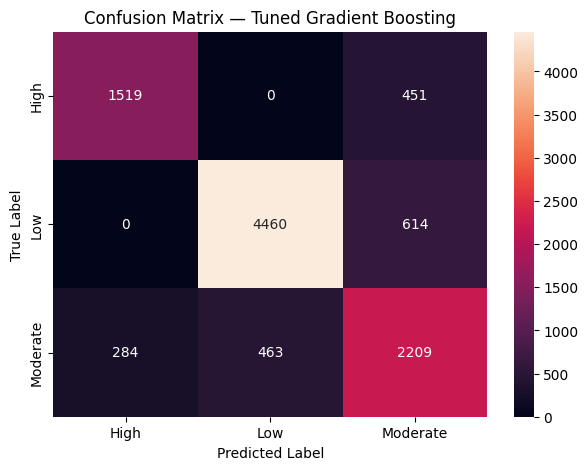

In [55]:
# Step 25.2 — Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["High", "Low", "Moderate"],
    yticklabels=["High", "Low", "Moderate"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Tuned Gradient Boosting")
plt.show()

In [56]:
# Step 25.3 — Feature Importance

best_gb_model = gb_random_search.best_estimator_

importance_values = best_gb_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Most Important Features")
print("--------------------------------")
print(feature_importance.head(20))

Top 20 Most Important Features
--------------------------------
                       Feature  Importance
6           num__Anxiety_Score    0.269043
84       cat__Stress_Level_Low    0.192594
85  cat__Stress_Level_Moderate    0.186175
7        num__Depression_Score    0.155075
8              num__Mood_Score    0.126059
9     num__Emotional_Stability    0.034075
83      cat__Stress_Level_High    0.029024
97     cat__Chronic_Stress_Yes    0.005624
17     num__Productivity_Score    0.001048
96      cat__Chronic_Stress_No    0.000960
2     num__Work_Hours_Per_Week    0.000204
11     num__Meditation_Minutes    0.000036
5             num__Sleep_Hours    0.000019
14           num__Gaming_Hours    0.000017
15    num__Coffee_Cups_Per_Day    0.000013
12      num__Screen_Time_Hours    0.000011
1      num__Monthly_Income_USD    0.000007
16      num__Life_Satisfaction    0.000004
3        num__Job_Satisfaction    0.000004
31          cat__Country_Italy    0.000004


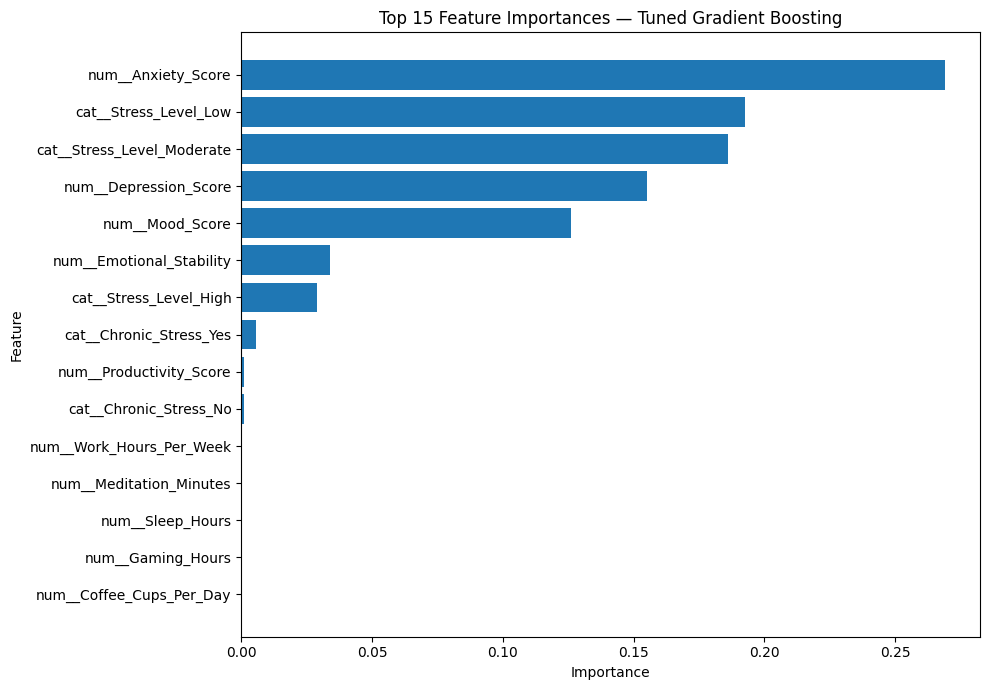

In [57]:
# Step 25.4 — Top 15 Feature Importance

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

# Final Machine Learning Model Evaluation

The classical machine learning stage involved training and comparing five model configurations: Logistic Regression, Decision Tree, Random Forest, baseline Gradient Boosting, and Tuned Gradient Boosting.

The tuned Gradient Boosting model achieved the best overall performance on the unseen test set, with an accuracy of **81.88%**, macro precision of **80.77%**, macro recall of **79.91%**, and macro F1-score of **80.22%**.

The classification report showed that the model performed best when predicting the **Low** burnout-risk class, with an F1-score of **0.89**. The **High** class achieved an F1-score of **0.81**, while the **Moderate** class was more difficult to predict, achieving an F1-score of **0.71**.

The confusion matrix showed that most classification errors involved the Moderate class being confused with either Low or High burnout risk. This suggests that the characteristics separating the middle-risk group from the other two groups are less distinct.

Feature importance analysis showed that **Anxiety Score, Stress Level, Depression Score, Mood Score, and Emotional Stability** were the most influential predictors used by the tuned Gradient Boosting model.

Overall, the classical machine learning stage established a strong baseline for the burnout-risk prediction task. The tuned Gradient Boosting classifier was selected as the final classical machine learning model and will be used as the benchmark for comparison with the neural network developed in the next stage.


In [10]:
# Step 26.2 — Find Dataset Path

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset/mental_health_burnout_prediction_dataset.csv


In [11]:
# Step 26.2 — Reload Dataset and Define Target

import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset/mental_health_burnout_prediction_dataset.csv"
)

target = "Burnout_Risk"

columns_to_drop = [
    "Person_ID",
    "Burnout_Score",
    "Mental_Health_Status",
    "AI_Wellness_Recommendation"
]

X = df.drop(columns=columns_to_drop + [target])
y = df[target]

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (50000, 40)
Feature matrix shape: (50000, 35)
Target shape: (50000,)


In [12]:
# Step 26.3 — Create Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training data shape: (40000, 35)
Testing data shape: (10000, 35)

Training target distribution:
Burnout_Risk
Low         20295
Moderate    11824
High         7881
Name: count, dtype: int64


In [13]:
# Step 26.4 — Define Numerical and Categorical Features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 19
Number of categorical features: 16

Numerical features:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days']

Categorical features:
['Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System']


In [14]:
# Step 26.5 — Build Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [15]:
# Step 26.6 — Transform Features for Neural Network

# Fit preprocessing only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (40000, 106)
Processed testing shape: (10000, 106)


In [18]:
# Step 26.7 — Prepare Processed Data for TensorFlow

# Convert sparse matrices to dense arrays if necessary
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>
Training shape: (40000, 106)
Testing shape: (10000, 106)


In [19]:
# Step 26.8 — Encode the Target Variable

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for number, label in enumerate(label_encoder.classes_):
    print(number, "=", label)

print("\nEncoded training target shape:", y_train_encoded.shape)
print("Encoded testing target shape:", y_test_encoded.shape)

Class mapping:
0 = High
1 = Low
2 = Moderate

Encoded training target shape: (40000,)
Encoded testing target shape: (10000,)


In [20]:
# Step 26.9 — Create Training and Validation Sets

from sklearn.model_selection import train_test_split

X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train_processed,
    y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded
)

print("Neural network training shape:", X_nn_train.shape)
print("Validation shape:", X_nn_val.shape)
print("Final test shape:", X_test_processed.shape)

print("\nTraining target distribution:")
print(y_nn_train.shape)

print("\nValidation target distribution:")
print(y_nn_val.shape)

Neural network training shape: (32000, 106)
Validation shape: (8000, 106)
Final test shape: (10000, 106)

Training target distribution:
(32000,)

Validation target distribution:
(8000,)


In [21]:
# Step 26.10 — Build the Neural Network Architecture

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(X_nn_train.shape[1],)),
    
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    
    Dense(3, activation="softmax")
])

model.summary()

2026-09-06 10:55:44.957001: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,027 (35.26 KB)

 Trainable params: 9,027 (35.26 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Step 26.11 — Compile the Neural Network

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Neural network compiled successfully.")

Neural network compiled successfully.


In [23]:
# Step 26.12 — Add Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",       # Watch validation loss
    patience=5,               # Stop after 5 epochs without improvement
    restore_best_weights=True # Restore the best-performing weights
)

print("Early stopping configured successfully.")

Early stopping configured successfully.


## Step 26.12 — Early Stopping

Early stopping is a regularization technique used to prevent overfitting during neural network training. It monitors the validation loss after each training epoch and stops training automatically when the validation loss no longer improves for a specified number of epochs (`patience=5`).

The parameter `restore_best_weights=True` ensures that the model keeps the weights from the epoch that achieved the lowest validation loss rather than the final training epoch. This helps improve the model's ability to generalize to unseen data.


In [24]:
# Step 26.13 — Train the Neural Network

history = model.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_nn_val, y_nn_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7995 - loss: 0.4269 - val_accuracy: 0.8066 - val_loss: 0.3947
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8137 - loss: 0.3848 - val_accuracy: 0.8045 - val_loss: 0.3952
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8172 - loss: 0.3773 - val_accuracy: 0.8080 - val_loss: 0.3824
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8182 - loss: 0.3702 - val_accuracy: 0.8117 - val_loss: 0.3823
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8201 - loss: 0.3649 - val_accuracy: 0.8070 - val_loss: 0.3833
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8229 - loss: 0.3586 - val_accuracy: 0.8037 - val_loss: 0.3872
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8249 - loss: 0.3520 - val_accuracy: 0.8008 - val_loss: 0.4014
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8275 - loss: 0.3457 - 

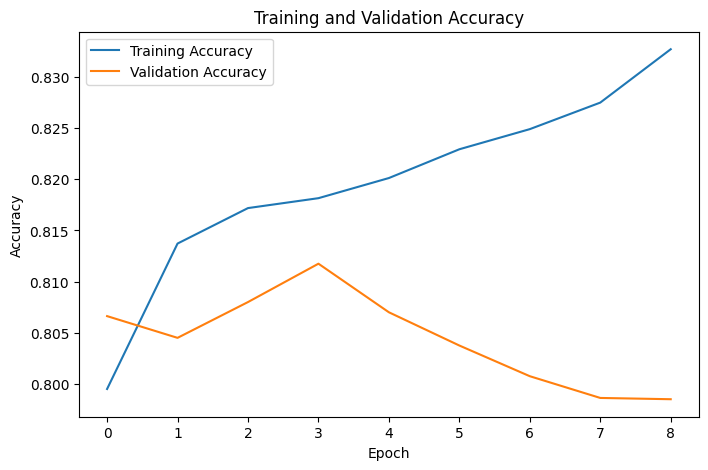

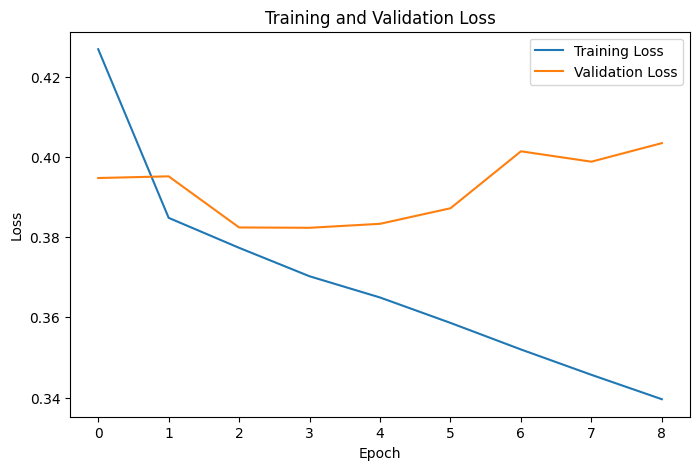

In [25]:
# Step 26.14 — Plot Training and Validation Performance

import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Step 26.14 — Training and Validation Performance

The training and validation accuracy curves were examined to assess the learning behaviour of the neural network.

Training accuracy increased consistently throughout the training process, reaching approximately 83% by the final recorded epoch. In contrast, validation accuracy improved initially and reached its highest value of approximately 81.17% around Epoch 4 before gradually declining.

The increasing gap between training and validation accuracy indicates the beginning of overfitting, where the model continues to improve on the training data but becomes less effective on unseen validation data.

The use of Early Stopping helped limit this overfitting by monitoring validation loss and restoring the model weights from the best-performing epoch.

In [26]:
# Step 26.15 — Evaluate the Neural Network on the Test Set

test_loss, test_accuracy = model.evaluate(
    X_test_processed,
    y_test_encoded,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8136 - loss: 0.3865

Test Loss: 0.3865361511707306
Test Accuracy: 0.8136000037193298


In [27]:
# Step 26.16 — Generate Neural Network Predictions

import numpy as np

# Generate probability predictions
y_nn_prob = model.predict(X_test_processed)

# Convert probabilities to predicted class labels
y_nn_pred = np.argmax(y_nn_prob, axis=1)

print("Prediction shape:", y_nn_pred.shape)
print("First 10 predictions:", y_nn_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Prediction shape: (10000,)
First 10 predictions: [1 2 1 1 1 1 1 1 2 0]


In [29]:
# Step 26.17 — Neural Network Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_nn_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.86      0.73      0.79      1970
         Low       0.88      0.90      0.89      5074
    Moderate       0.67      0.71      0.69      2956

    accuracy                           0.81     10000
   macro avg       0.80      0.78      0.79     10000
weighted avg       0.82      0.81      0.81     10000



In [30]:
# Step 26.18 — Neural Network Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_nn = confusion_matrix(
    y_test_encoded,
    y_nn_pred
)

print("Confusion Matrix:")
print(cm_nn)

Confusion Matrix:
[[1445    0  525]
 [   0 4580  494]
 [ 244  601 2111]]


## Step 26.18 — Neural Network Confusion Matrix

The confusion matrix was used to examine the classification errors made by the neural network across the three burnout-risk categories.

The model correctly classified 1,445 High-risk observations, 4,580 Low-risk observations, and 2,111 Moderate-risk observations.

The Moderate class was the most difficult category to predict. A substantial number of Moderate observations were incorrectly classified as Low or High, while High and Low observations were also occasionally classified as Moderate.

An important observation is that there were no direct High-to-Low or Low-to-High classification errors. Most errors occurred between the Moderate class and the other two classes, suggesting that the middle-risk category has less distinct characteristics.

Overall, the confusion matrix is consistent with the classification report, which showed that the Low class had the strongest performance (F1-score = 0.89), while the Moderate class had the lowest performance (F1-score = 0.69).

In [31]:
# Step 26.19 — Compare Neural Network vs Tuned Gradient Boosting

comparison = {
    "Model": [
        "Tuned Gradient Boosting",
        "Neural Network"
    ],
    "Accuracy": [
        0.8188,
        test_accuracy
    ],
    "Precision": [
        0.807715,
        0.80
    ],
    "Recall": [
        0.799117,
        0.78
    ],
    "F1-Score": [
        0.802204,
        0.79
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

                     Model  Accuracy  Precision    Recall  F1-Score
0  Tuned Gradient Boosting    0.8188   0.807715  0.799117  0.802204
1           Neural Network    0.8136   0.800000  0.780000  0.790000


## Step 26.19 — Neural Network vs Classical Machine Learning

The neural network was compared with the tuned Gradient Boosting classifier using the same unseen test dataset.

The tuned Gradient Boosting model achieved the best overall performance, with an accuracy of 81.88% and a macro F1-score of 80.22%. The neural network achieved an accuracy of 81.36% and a macro F1-score of 79.00%.

Gradient Boosting therefore outperformed the neural network across accuracy, precision, recall, and macro F1-score. However, the performance difference was relatively small, with only a 0.52 percentage-point difference in accuracy.

The neural network nevertheless demonstrated strong predictive performance and successfully learned meaningful patterns from the 106 processed input features. Both models struggled most with distinguishing the Moderate burnout-risk class.

Based on the test-set results, the tuned Gradient Boosting classifier was selected as the best-performing model for this dataset.

# Final Project Conclusion

This project developed machine learning and deep learning models to predict employee burnout risk using the Mental Health & Burnout Prediction Dataset.

The dataset contained 50,000 observations and 40 variables. The target variable was `Burnout_Risk`, consisting of three categories: Low, Moderate, and High. During exploratory analysis, potential target leakage was identified. `Burnout_Score` was excluded because the burnout-risk categories were directly related to its score ranges. `Mental_Health_Status` was also excluded because of its near-deterministic relationship with the target, while `AI_Wellness_Recommendation` was excluded because it represented a recommendation output rather than a meaningful predictor.

The data was divided using an 80/20 stratified train-test split. Missing numerical values were handled using median imputation and standardized, while categorical variables were imputed using the most frequent category and transformed using one-hot encoding. The 35 predictors were transformed into 106 model-ready features.

Five classical machine learning configurations were evaluated. The tuned Gradient Boosting classifier achieved the strongest performance, with a test accuracy of 81.88% and a macro F1-score of 80.22%. Feature importance analysis showed that Anxiety Score, Stress Level, Depression Score, Mood Score, and Emotional Stability were the most influential predictors used by the model.

A neural network was then developed using 106 input features, two hidden layers containing 64 and 32 neurons, and a three-neuron Softmax output layer. Early stopping was used to reduce overfitting. The neural network achieved a test accuracy of 81.36% and a macro F1-score of 79.00%.

When the two approaches were compared, the tuned Gradient Boosting model slightly outperformed the neural network across all major evaluation metrics. Therefore, Gradient Boosting was selected as the final model for this dataset.

Overall, the project demonstrated an end-to-end predictive modelling workflow, including exploratory data analysis, leakage detection, preprocessing, classical machine learning, hyperparameter tuning, neural network development, evaluation, and model comparison. The results demonstrate that machine learning can effectively identify patterns associated with different levels of burnout risk, although distinguishing the Moderate-risk group remains the main predictive challenge.